In [1]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
library(data.table)
library(ggplot2)
library(ggsci)

In [2]:
devtools::load_all("utils/modules/R/phasingtools/")

i Loading phasingtools

Loading required package: Hmisc

Loading required package: lattice

Loading required package: survival

Loading required package: Formula


Attaching package: 'Hmisc'


The following objects are masked from 'package:base':

    format.pval, units


Loading required package: stringr

! Skipping missing files: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasingtools/R/aggr_ser_by_site.R

! Adding files missing in collate: /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasingtools/R/aggr_ser_by_pos.R, /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasingtools/R/bp_betwen_single_switches.R, /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasingtools/R/extract_chunk_id.R, /gpfs3/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/utils/modules/R/phasingtools/

In [3]:
sites <- "/well/lindgren/UKBIOBANK/dpalmer/wes_200k/ukb_wes_qc/data/variants/08_final_qc.keep.variant_list"
variants <- fread(sites)

In [4]:
library(RColorBrewer)




In [5]:
# setup color scale
col_genome <- "#7BA98A"
col_exome <- "#65B8EF" #"#81A8C9"
my_colors <- c(col_genome, col_exome)
names(my_colors) <- c("Genotyping Array", "Whole Exome Sequencing")
fill_scale <- scale_fill_manual(name = "Variants", values = my_colors)
color_scale <- scale_color_manual(name = "Variants", values = my_colors)

In [6]:
# setup orders
all_chunks <- paste0("", sort(1:20))
autosomes <- paste0("chr",1:22)

In [52]:
d <- fread("data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr22.txt")
nrow(d)
length(unique(d$trio_id))

[1] 210157

[1] 95

In [12]:
d <- fread("data/phased/wes_union_calls/with_parents_test_unphased/ukb_eur_wes_union_calls_200k_chr21.txt")
nrow(d)
length(unique(d$trio_id)) # why did we lose 3 children?

[1] 162138

[1] 92

In [42]:



aggregate_by_chrom_and_mac_bin <- function(files, mac_bin, variants){
    lst <- lapply(files, function(file){
        d <- fread_phased_sites(file)
        d$wes_variant <- d$locus %in% variants$locus
        d$mac_bin <- cut(d$MAC, breaks = mac_bin)
        counts <- aggregate(switches ~ wes_variant + mac_bin + CHR, data = d, FUN = sum)
        tested <- aggregate(switches ~ wes_variant + mac_bin + CHR, data = d, FUN = length)
        counts <- data.table(counts, tested = tested$switches)
        return(counts)
    })
    return(lst)
}


In [43]:
ligated_dir <- "data/phased/wes_scaffold_calls/200k_from_500k/test/
files <- c("data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr21.txt")
#sites <- "/well/lindgren/UKBIOBANK/dpalmer/wes_200k/ukb_wes_qc/data/variants/08_final_qc.keep.variant_list"

In [44]:
files <- list.files(ligated_dir, pattern = ".txt", full.names = TRUE)
files

[1] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr10.txt"
 [2] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr11.txt"
 [3] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr12.txt"
 [4] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr13.txt"
 [5] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr14.txt"
 [6] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr15.txt"
 [7] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr16.txt"
 [8] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr17.txt"
 [9] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr18.txt"
[10] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr19.txt"
[11] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr2.txt" 
[12] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr20.txt"
[13] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr21.txt"
[14] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr22.txt"
[15] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr3.txt" 
[16] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr4.txt" 
[17] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr5.txt" 
[18] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr6.txt" 
[19] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr7.txt" 
[20] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr8.txt" 
[21] "data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr9.txt"

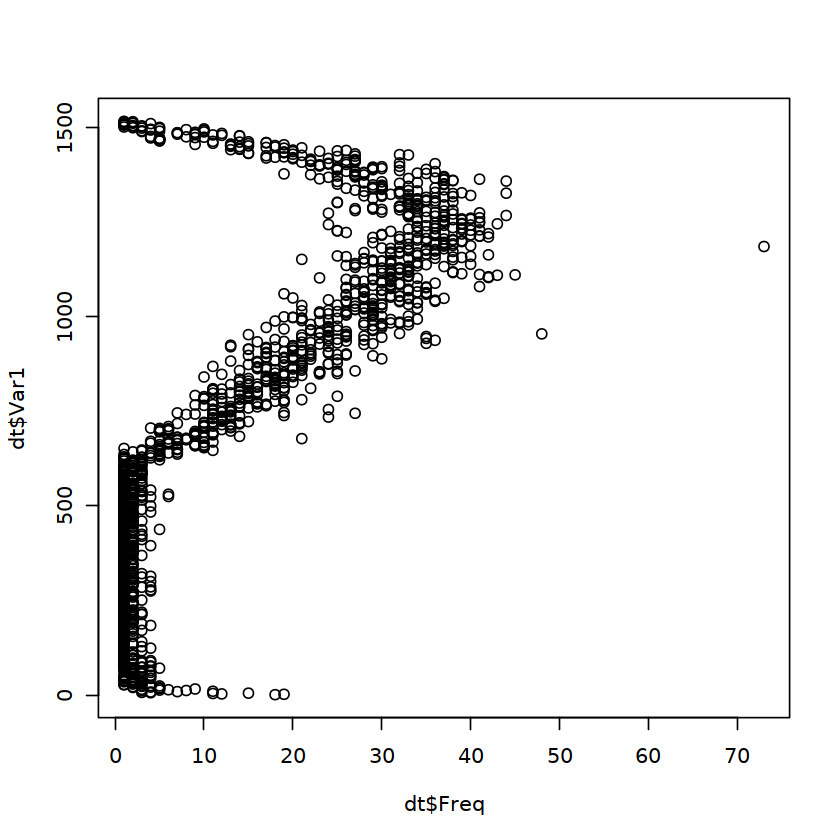

In [26]:
dt <- data.frame(table(d5$AC))
plot(dt$Freq, dt$Var1)

In [5]:
d0 <- fread_phased_sites("data/phased/wes_scaffold_calls/200k_from_500k/test/ukb_wes_scaffold_calls_200k_from_500k_shapeit5_dp4_sequencing_chr21.txt")
d1 <- fread_phased_sites("data/phased/wes_scaffold_calls/200k_from_500k/test/ukb_wes_scaffold_calls_200k_from_500k_shapeit4_dp5_sequencing_chr21.txt")
#d0 <- fread_phased_sites("data/phased/wes_scaffold_calls/200k_from_500k/merge_parents/ukb_wes_scaffold_calls_200k_from_500k_shapeit5_chr21.txt")
d2 <- fread_phased_sites("data/phased/wes_union_calls/benchmark/200k/ukb_eur_wes_union_calls_200k_phased_shapeit4_chr21.txt")
d3 <- fread_phased_sites("data/phased/wes_union_calls/benchmark/200k/ukb_wes_union_calls_200k_phased_whatshap_shapeit4_chr21.txt")
d4 <- fread_phased_sites("data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr21.txt")
d5 <- fread_phased_sites("data/phased/wes_union_calls/200k/shapeit5/parents/ukb_wes_union_calls_200k_shapeit5_parents_chr21.txt")
d6 <- fread_phased_sites("data/phased/wes_union_calls/200k/shapeit5/parents/ukb_wes_union_calls_200k_shapeit5_parents_chr21_sequencing.txt")

In [6]:
print(nrow(d0)); print(nrow(d1)); print(nrow(d2)); print(nrow(d3)); print(nrow(d4)); print(nrow(d5)); print(nrow(d6))

[1] 162557
[1] 162653
[1] 166853
[1] 166855
[1] 173024
[1] 162340
[1] 166843


In [7]:
d0all <- d0
d1all <- d1

In [8]:
d0$wes_variant <- d0$locus %in% variants$locus
d1$wes_variant <- d1$locus %in% variants$locus
d2$wes_variant <- d2$locus %in% variants$locus
d3$wes_variant <- d3$locus %in% variants$locus
d4$wes_variant <- d4$locus %in% variants$locus
d5$wes_variant <- d5$locus %in% variants$locus
d6$wes_variant <- d6$locus %in% variants$locus

In [9]:
print(sum(d0$wes_variant)); 
print(sum(d1$wes_variant));
print(sum(d2$wes_variant));
print(sum(d3$wes_variant));
print(sum(d4$wes_variant));
print(sum(d5$wes_variant));
print(sum(d6$wes_variant));

[1] 21677
[1] 21757
[1] 21781
[1] 21781
[1] 27925
[1] 21776
[1] 21776


In [10]:
d0 <- d0[d0$wes_variant]
d1 <- d1[d1$wes_variant]
d2 <- d2[d2$wes_variant]
d3 <- d3[d3$wes_variant]
d4 <- d4[d4$wes_variant]
d5 <- d5[d5$wes_variant]
d6 <- d6[d6$wes_variant]
ser0 <- sum(d0$switches) / nrow(d0)
ser1 <- sum(d1$switches) / nrow(d1)
ser2 <- sum(d2$switches) / nrow(d2)
ser3 <- sum(d3$switches) / nrow(d3)
ser4 <- sum(d4$switches) / nrow(d4)
ser5 <- sum(d5$switches) / nrow(d5)
ser6 <- sum(d6$switches) / nrow(d6)

In [11]:
print(paste(sum(d0$switches),"/",nrow(d0))) # SHAPEIT5 - DP4 --modulo 0.0002
print(paste(sum(d1$switches),"/",nrow(d1))) # SHAPEIT4 - DP5 --sequencing
print(paste(sum(d2$switches),"/",nrow(d2))) # SHAPEIT4 - DP4 --sequencing
print(paste(sum(d3$switches),"/",nrow(d3))) # SHAPEIT4 - DP4 --sequencing --use-PS 0.0001
print(paste(sum(d4$switches),"/",nrow(d4))) # SHAPEIT4 - DP4 --sequencing --?
print(paste(sum(d5$switches),"/",nrow(d5))) # SHAPEIT5 - DP4 common then rare
print(paste(sum(d6$switches),"/",nrow(d6))) # SHAPEIT5 -- sequencing

[1] "579 / 21677"
[1] "52 / 21757"
[1] "54 / 21781"
[1] "61 / 21781"
[1] "53 / 27925"
[1] "45 / 21776"
[1] "48 / 21776"


In [11]:
print(ser0); print(ser1); print(ser2); print(ser3); print(ser4); print(ser5)

[1] 0.02671034
[1] 0.002390035
[1] 0.002479225
[1] 0.002800606
[1] 0.001897941
[1] 0.002066495


In [94]:
d0all_sites <- aggr_ser_by_site(d0all)
d1all_sites <- aggr_ser_by_site(d1all)
d0_sites <- aggr_ser_by_site(d0)
d1_sites <- aggr_ser_by_site(d1)
d2_sites <- aggr_ser_by_site(d2)
d3_sites <- aggr_ser_by_site(d3)
d4_sites <- aggr_ser_by_site(d4)

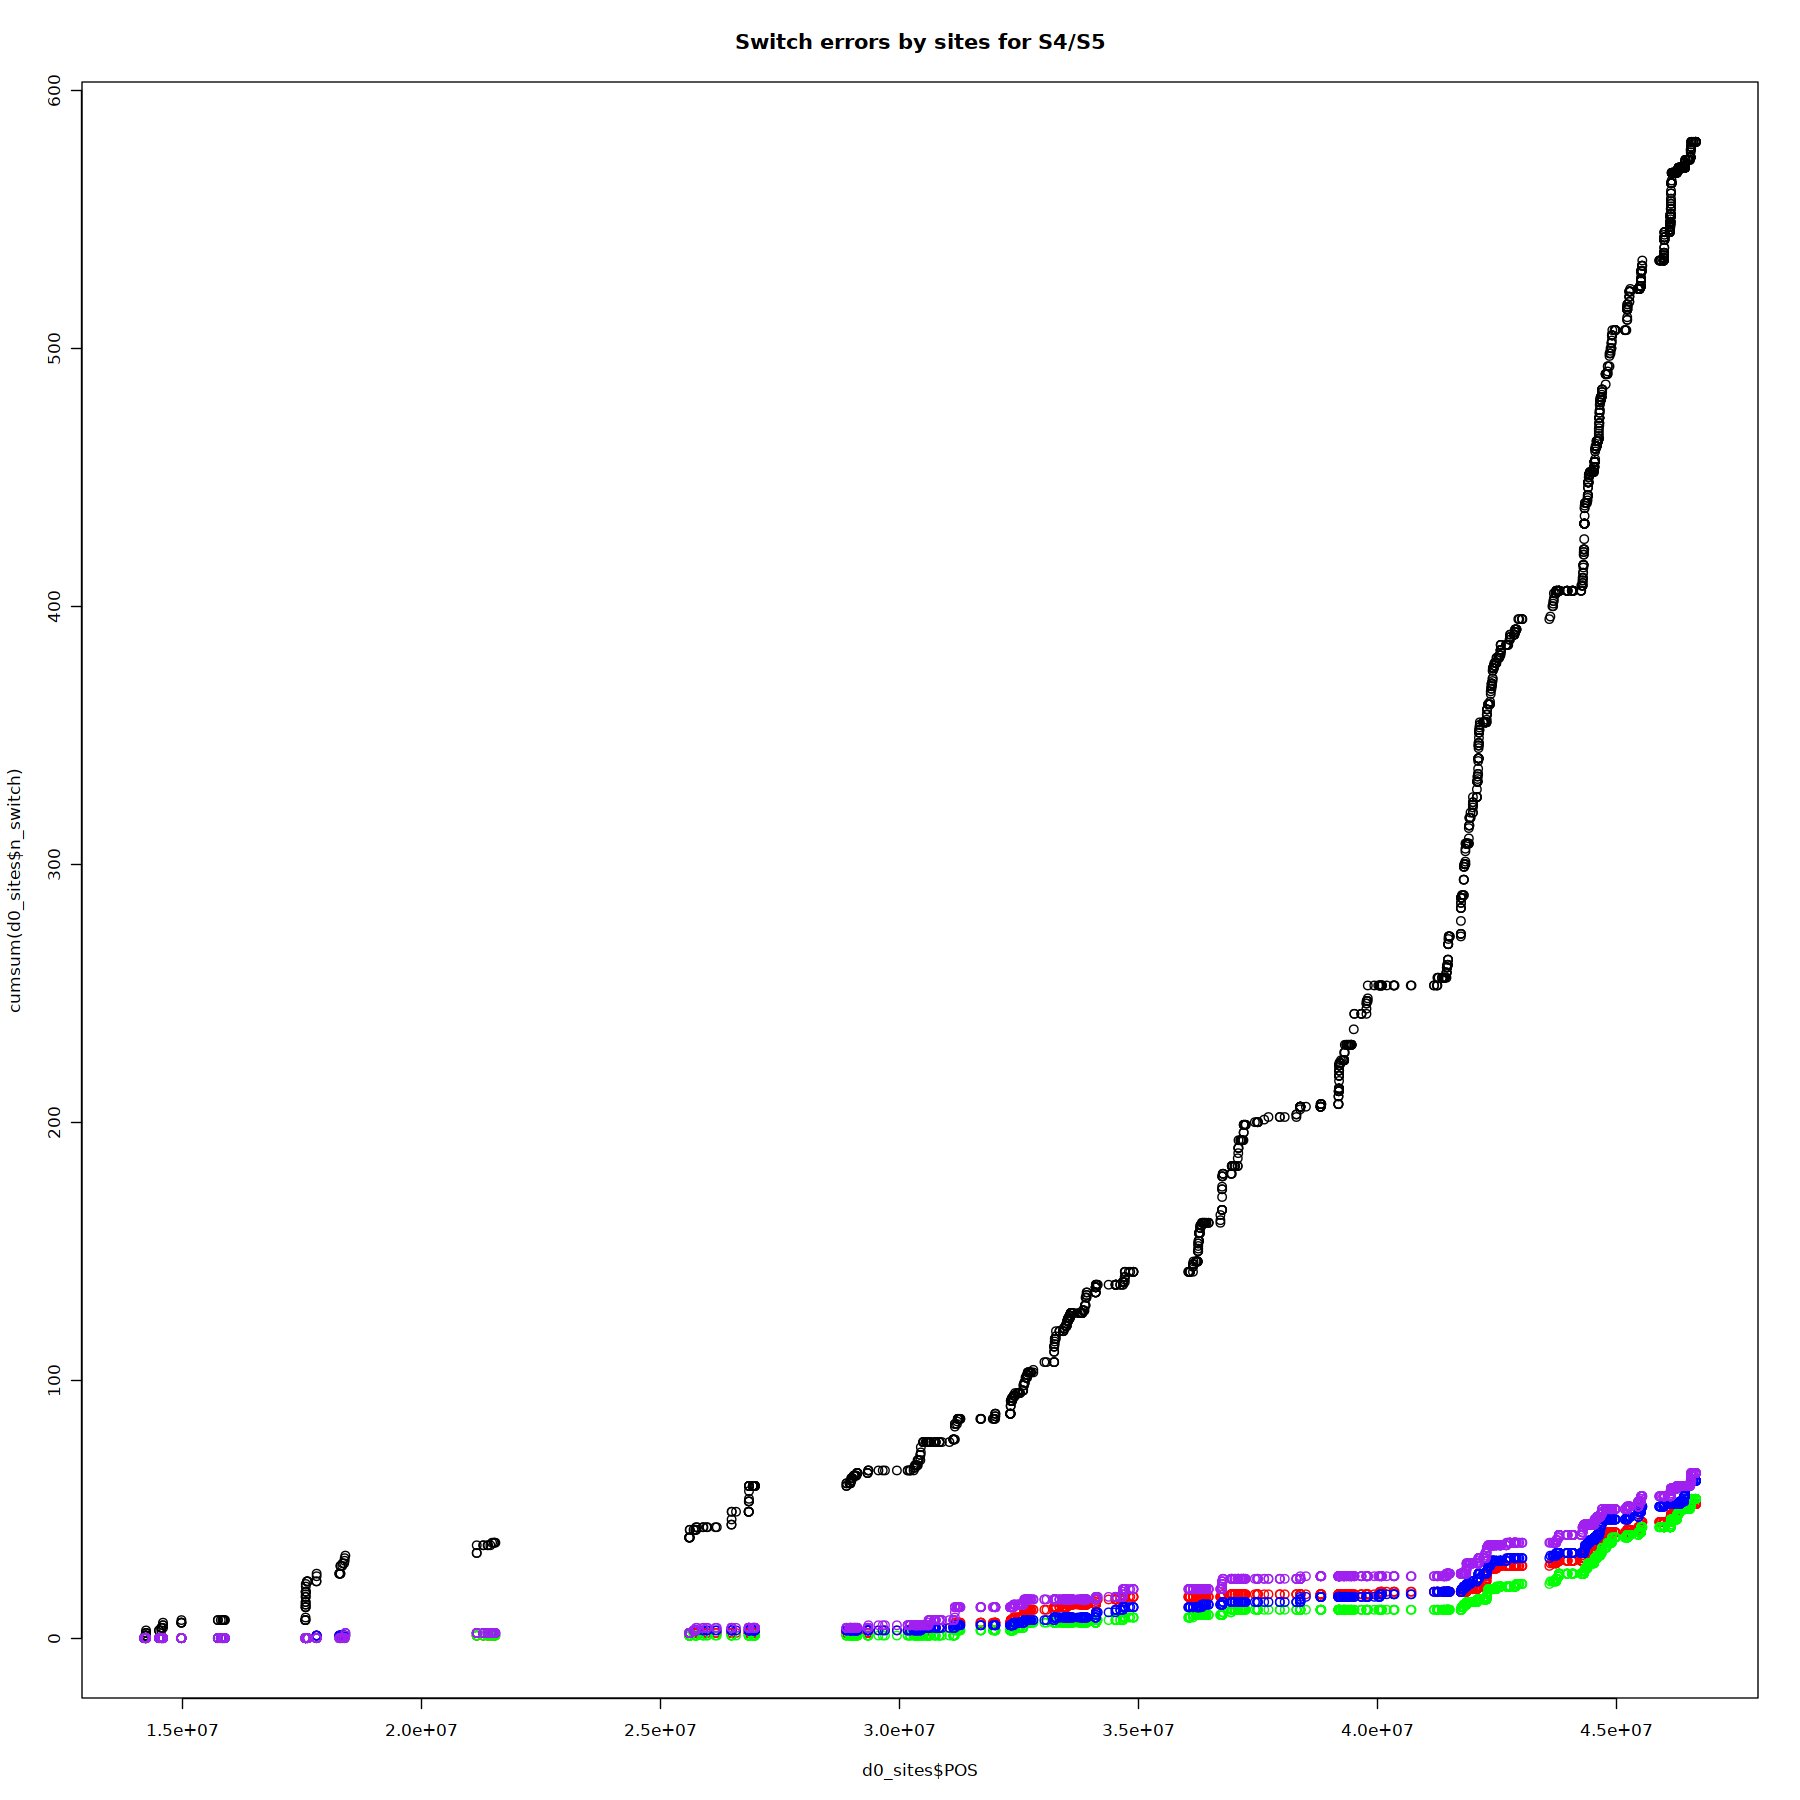

In [95]:
plot(x=d0_sites$POS, y=cumsum(d0_sites$n_switch), main = "Switch errors by sites for S4/S5")
points(x=d1_sites$POS, y=cumsum(d1_sites$n_switch), col = 'red')
points(x=d2_sites$POS, y=cumsum(d2_sites$n_switch), col = 'green')
points(x=d3_sites$POS, y=cumsum(d3_sites$n_switch), col = 'blue')
points(x=d4_sites$POS, y=cumsum(d4_sites$n_switch), col = 'purple')

In [109]:
d0all_sites$in_wes <- d0all_sites$POS %in% d0_sites$POS
d1all_sites$in_wes <- d1all_sites$POS %in% d1_sites$POS

In [110]:
options(repr.plot.width = 26, repr.plot.height = 18, repr.plot.res = 100)

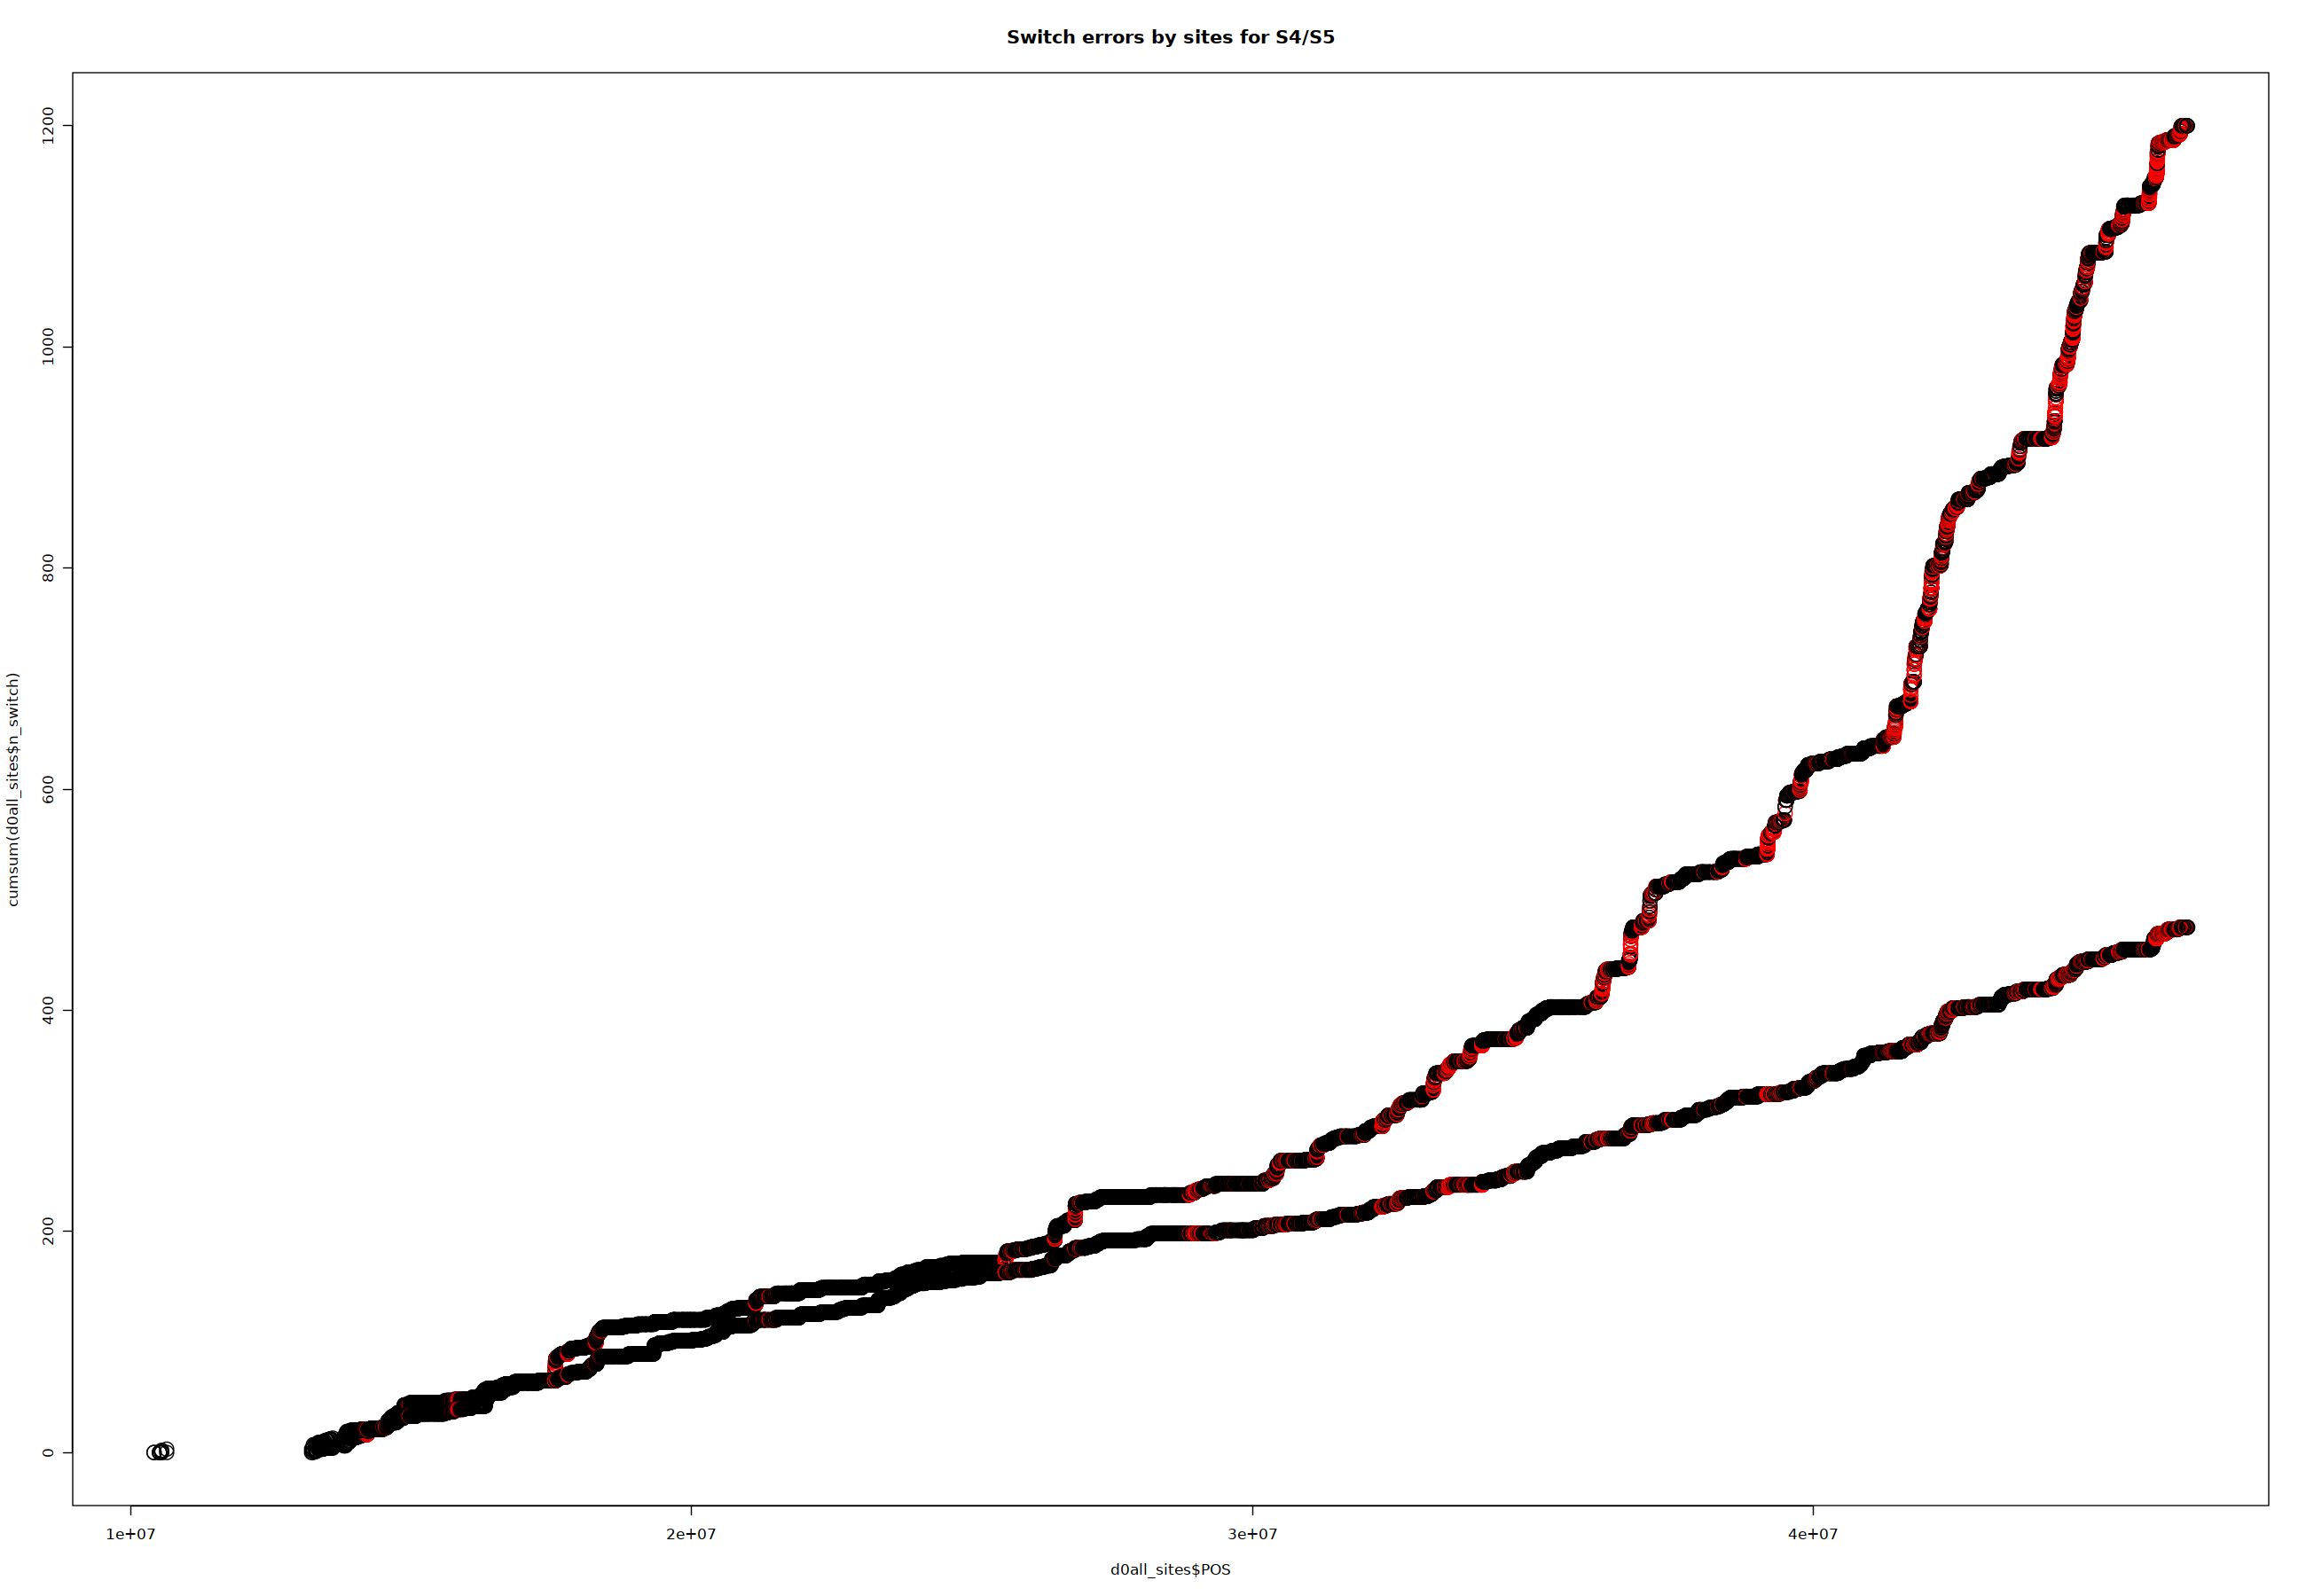

In [111]:
plot(x=d0all_sites$POS, y=cumsum(d0all_sites$n_switch), col = ifelse(d0all_sites$in_wes, "red", "black"), cex = 2, main = "Switch errors by sites for S4/S5")
points(x=d1all_sites$POS, y=cumsum(d1all_sites$n_switch), col = ifelse(d1all_sites$in_wes, "red", "black"), cex = 2)

In [106]:

bp_between_single_switches <- function(switches, pos){
    stopifnot(!is.null(pos))
    stopifnot(length(switches) == length(pos))
    # get position for single switches
    single_switch_idx <- which(id_single_switch_errors(switches))
    single_switch_pos <- pos[single_switch_idx]
    # get distance between each point
    n <- length(single_switch_pos)
    ranges <- unlist(lapply(1:(n-1), function(idx){
        x1 <- single_switch_pos[idx]
        x2 <- single_switch_pos[idx+1]
        distance <- x2-x1
        return(distance)
    }))
    # get position for all switch errors
    #metric <- ifelse(unit == "Mb", 1e+6, unit)
    return(ranges)
    
}






In [76]:
head(d)

ID,CHR,POS,REF,ALT,MAF,AF,AC,AN,HWE,trio_id,index,switch,switches
<chr>,<chr>,<int>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<int>,<int>,<int>
.,chr22,15329305,A,G,0.0237328,0.976267,389802,399278,5.60519e-45,21,1,0,0
.,chr22,15329305,A,G,0.0237328,0.976267,389802,399278,5.60519e-45,48,1,0,0
.,chr22,15329305,A,G,0.0237328,0.976267,389802,399278,5.60519e-45,66,1,0,0
.,chr22,15382411,T,G,0.0414121,0.958588,382768,399304,0.00000e+00,1,2,0,0
.,chr22,15382411,T,G,0.0414121,0.958588,382768,399304,0.00000e+00,16,2,0,0
.,chr22,15382411,T,G,0.0414121,0.958588,382768,399304,0.00000e+00,37,2,0,0


In [152]:
#d <- fread_phased_sites("data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr20.txt")
d <- fread_phased_sites("data/phased/wes_union_calls/with_parents/ukb_eur_wes_union_calls_200k_chr20.txt")
d$wes_variant <- d$locus %in% variants$locus
d <- d[d$wes_variant,]

In [223]:
test <- get_switch_error_per_gene(d$POS, d$SWITCHES, 20)

In [224]:
median(test[test$sites > 0, ]$sites)

[1] 74.5

In [190]:
phased_genes <- get_switch_error_per_gene(d$POS, d$SWITCHES, 22)


In [192]:
n_biomart_genes <- nrow(phased_genes) 
phased_genes <- phased_genes[phased_genes$sites > 0, ]
n_genes_with_trio_sites <- nrow(phased_genes) 
n_phased_genes_wo_errors <- sum(phased_genes$errors == 0)


In [196]:
n_phased_genes_wo_errors

[1] 227

In [102]:
sum(id_single_switch_errors(d$switches))
sum(id_phase_errors(d$switches)) 

[1] 90

[1] 90

In [104]:
print(paste(sum(d$switches),"/",nrow(d)))

[1] "90 / 56827"


In [81]:
# aggregate switch errors by genomic position
switches_subset <- d
#switches_subset <- switches_subset[ is_snv(switches_subset$REF, switches_subset$ALT), ]
switches_by_genome <- aggregate( switches ~ CHR + POS + trio_id, data = switches_subset, FUN = sum)
switches_by_genome <- switches_by_genome[order(switches_by_genome$POS),]

In [56]:
trio_ids <- unique(switches_subset$trio_id)

In [57]:
length(unique(trio_ids))

[1] 95

In [58]:
lst <- lapply(trio_ids, function(id){
    trio_switches <- switches_by_genome[switches_by_genome$trio_id %in% id,]
    distance <- distance_between_single_switches(trio_switches$switches, trio_switches$POS)
    metric <- 1e+6
    return(metric / distance)
})

In [59]:
mean(na.omit(unlist(lst)))

[1] 12.39064

In [77]:
switches_by_genome$cumsum <- cumsum(switches_by_genome$switches)

In [78]:
sum(switches_subset$switches) / nrow(switches_subset)

[1] 0.002574266

In [79]:
nrow(switches_subset)

[1] 210157

In [80]:
sum(switches_subset$switches)

[1] 541

In [64]:
sum(switches_subset$switches)

[1] 541

In [65]:
nrow(switches_subset)

[1] 210157

In [66]:
print(nrow(switches_by_genome))
print(length(unique(switches_by_genome$POS)))

[1] 198497
[1] 13701


In [67]:
pos <- switches_by_genome$POS
switches <- switches_by_genome$switches
single_switch_idx <- which(id_single_switch_errors(switches))
single_switch_pos <- pos[single_switch_idx]



In [68]:
mean(1e+6 / ranges)

ERROR: Error in mean(1e+06/ranges): object 'ranges' not found


In [ ]:
sum(id_single_switch_errors(d$switches))

In [69]:
sum(id_phase_errors(d$switches))

[1] 541

In [70]:
sum(id_single_switches(c(0,1,0,1,0,1,0,1)))

ERROR: Error in id_single_switches(c(0, 1, 0, 1, 0, 1, 0, 1)): could not find function "id_single_switches"


In [72]:
#switch_positions <- d$POS[which(d$switches != 0)]
#switch_positions

In [25]:
cut(as.numeric(d$MAC), breaks = c(10, 100))

factor(0)
Levels: (10,100]

In [52]:
mac_bins <- c(Inf,1000, 100, 30, 20, 10, 5,3,1,0)
#aggregate_by_mac_bin(files, mac_bin, variants)

In [56]:
aggr_d <- aggregate_by_chrom_and_mac_bin(files, mac_bins, variants = variants)

In [60]:
head(aggr_d)

wes_variant,mac_bin,CHR,switches,tested
<lgl>,<fct>,<chr>,<int>,<int>
FALSE,"(1,3]",chr10,13,28
TRUE,"(1,3]",chr10,40,129
FALSE,"(3,5]",chr10,0,6
TRUE,"(3,5]",chr10,3,82
FALSE,"(5,10]",chr10,0,10
TRUE,"(5,10]",chr10,4,154
FALSE,"(10,20]",chr10,1,12
TRUE,"(10,20]",chr10,4,188
FALSE,"(20,30]",chr10,1,7


In [63]:
colnames(aggr_d)

NULL

In [57]:
aggr_switches <- aggregate(switches ~ wes_variant + mac_bin, data = aggr_d, FUN = sum)

ERROR: Error in eval(predvars, data, env): object 'switches' not found


In [ ]:

aggr_tested <- aggregate(tested ~ wes_variant + mac_bin, data = aggr_d, FUN = sum)
aggr_counts <- data.table(aggr_switches, tested = aggr_tested$tested)
aggr_counts <- calc_binom_ci(list(aggr_counts))
aggr_counts$wes_label <- ifelse(aggr_counts$wes_variant, "Whole Exome Sequencing","Genotyping Array")
print(table(aggr_counts$mac_bin))

# Chunks by chromosome 

In [5]:
path <- "data/phased/validation/220713_ukb_eur_wes_union_calls_chunks_by_ser.txt.gz"
d <- fread(path)
d$wes_label <- factor(d$wes_label)
d$chunk_current_w_label <- paste0("p",d$chunk_current)

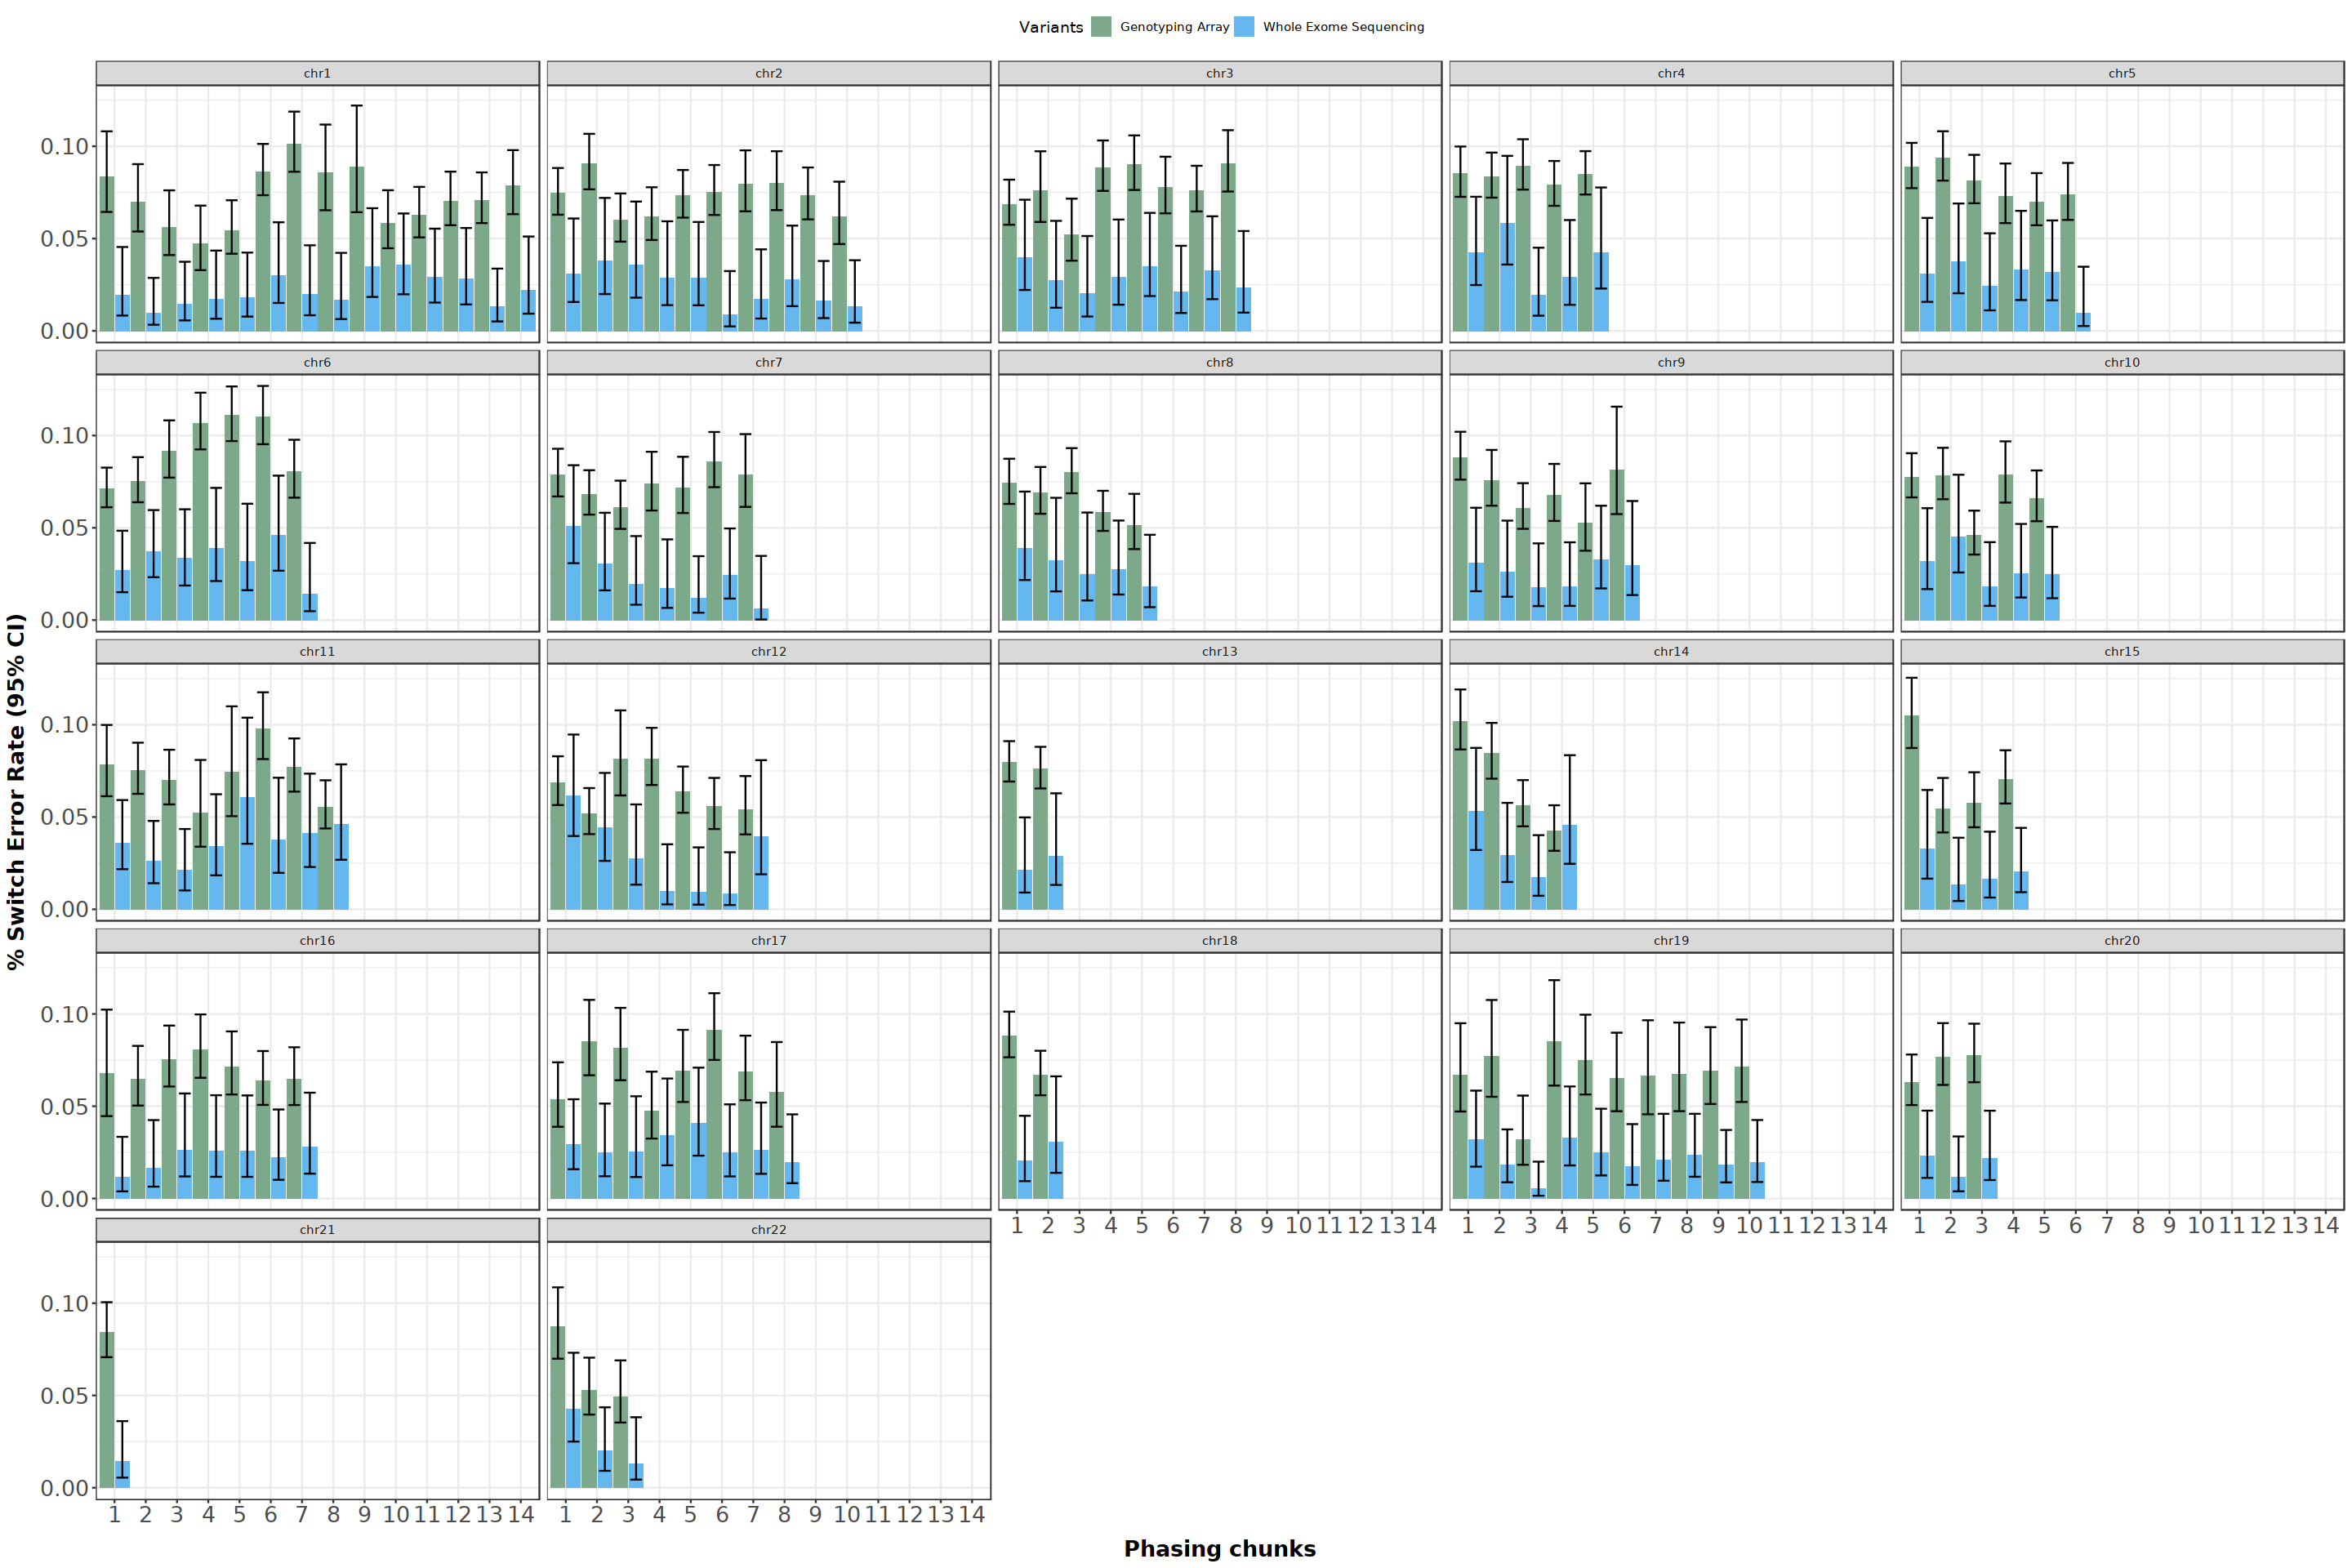

In [6]:
options(repr.plot.width=24, repr.plot.height=16)
pd <- position_dodge(1)
p1 <- ggplot(d,
   aes(
       #x=factor(chunk_current_w_label, levels = all_chunks),
       x=factor(chunk_current),
       y=100*pointest,
       ymax = 100*upper,
       ymin = 100*lower,
       fill = wes_label,
   )) +
    theme_bw() +
    geom_bar(stat = 'identity', position = pd, size = 1) +
    geom_errorbar(stat='identity', position = pd,width = 0.75) +
    ylab('% Switch Error Rate (95% CI)') + 
    xlab('Phasing chunks') +
    fill_scale +
    labs(fill = "Hello") +
    scale_y_continuous(breaks=scales::pretty_breaks(n=4)) +
    #scale_x_continuous(breaks=scales::pretty_breaks(n=7)) +
    facet_wrap(~factor(CHR, levels = autosomes)) +
    theme(
        legend.position = "top",
        axis.text=element_text(size=16),
        axis.title=element_text(size=16,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5)
       # axis.text.x = element_text(angle = 0, vjust = 1, hjust=0)
    )
    p1

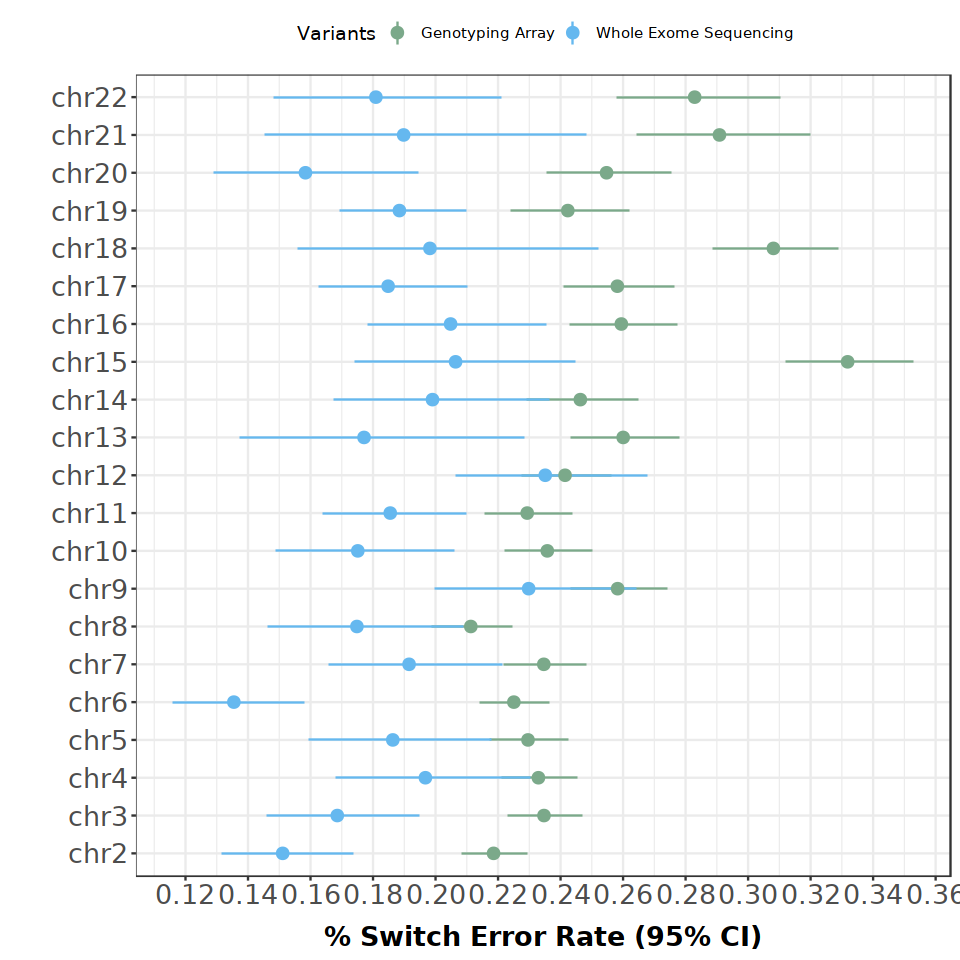

In [6]:
options(repr.plot.width=8, repr.plot.height=8)
path <- "data/phased/validation/221014_switch_error_rates_ser_by_chrom.txt.gz"
d <- fread(path)
d$wes_label <- factor(d$wes_label)
d$chr <- factor(d$CHR, levels = autosomes)
pd <- position_dodge(0.7)
p1 <- ggplot(d,
   aes(
       y=chr,
       x=100*pointest,
       xmax = 100*upper,
       xmin = 100*lower,
       color = factor(wes_label)
   )) +
    theme_bw() +
    geom_pointrange(size = 0.5) +
    labs(color = "") +
    xlab('% Switch Error Rate (95% CI)') + ylab('') +
    color_scale +
    scale_x_continuous(breaks=scales::pretty_breaks(n=10)) +
    theme(
        legend.position = "top",
        axis.text=element_text(size=16),
        axis.title=element_text(size=16,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5)
    )

p1

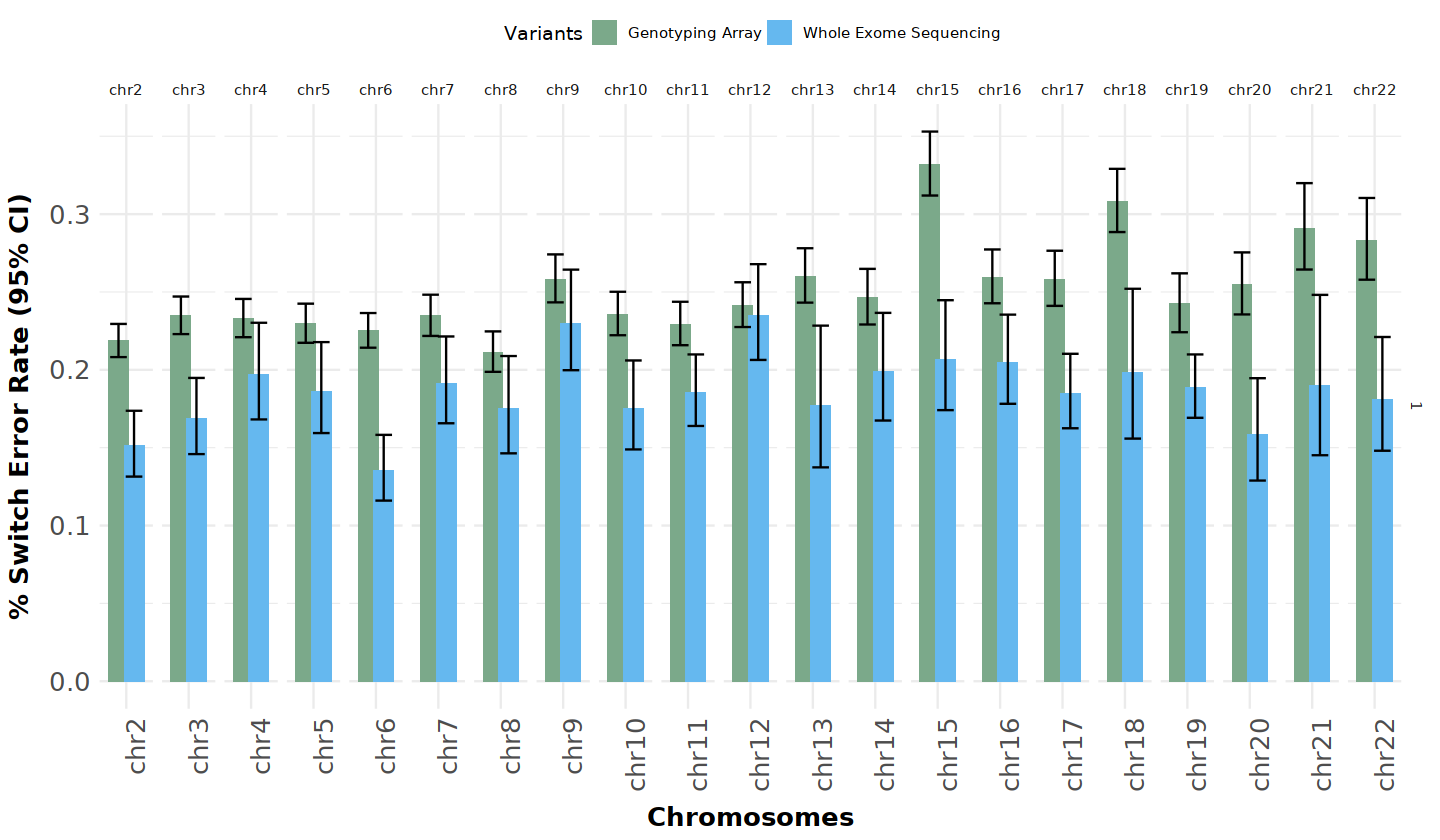

In [7]:
options(repr.plot.width=12, repr.plot.height=7)
p1 <- ggplot(d,
   aes(
       x=chr,
       y=100*pointest,
       ymax = 100*upper,
       ymin = 100*lower,
       fill = wes_label,
   )) +
    theme_minimal() +
    geom_bar(stat = 'identity', position = pd, size = 1) +
    geom_errorbar(stat='identity', position = pd, width = 0.75) +
    ylab('% Switch Error Rate (95% CI)') + 
    xlab('Chromosomes') +
    fill_scale +
    labs(fill = "Hello") +
    scale_y_continuous(breaks=scales::pretty_breaks(n=4)) +
    #scale_x_continuous(breaks=scales::pretty_breaks(n=7)) +
    theme(
        legend.position = "top",
        axis.text=element_text(size=15),
        axis.title=element_text(size=15,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 90, vjust = 1, hjust=0)
    ) +
    facet_grid(1~chr, scales = "free_x") 
    p1

ggsave("derived/plots/220908_switch_errors_by_chromosome.pdf", width = 10, height = 6)

In [10]:
total_switches <- sum(d[d$wes_variant]$switches)
total_tested <- sum(d[d$wes_variant]$tested)
total_errors <- cbind(
    data.frame(switches = total_switches, tested = total_tested),
    Hmisc::binconf(total_switches, total_tested)
)
total_errors

switches,tested,PointEst,Lower,Upper
<int>,<int>,<dbl>,<dbl>,<dbl>
548,2044234,0.0002680711,0.0002465492,0.0002914711


In [11]:
total_switches <- sum(d[!d$wes_variant]$switches)
total_tested <- sum(d[!d$wes_variant]$tested)
total_errors <- cbind(
    data.frame(switches = total_switches, tested = total_tested),
    Hmisc::binconf(total_switches, total_tested)
)
total_errors

switches,tested,PointEst,Lower,Upper
<int>,<int>,<dbl>,<dbl>,<dbl>
7053,9495805,0.000742749,0.0007256221,0.0007602799


# SER by MAF Bins

In [12]:
#d$maf_bin_new <- d$maf_bin
#for (i in 1:nrow(ds)) d$maf_bin_new <- gsub(ds$from1[i], ds$expr[i], d$maf_bin_new)
#for (i in 1:nrow(ds)) d$maf_bin_new <- gsub(ds$from2[i], ds$expr[i], d$maf_bin_new)



from <- c('(1e-06,1e-05]', '(1e-06,1e-05]', '(1e-05,0.0001]', 
          '(1e-05,0.0001]', '(0.0001,0.001]','(0.0001,0.001]',
          '(0.001,0.01]','(0.001,0.01]','(0.01,0.1]',
          '(0.01,0.1]','(0.1,1]','(0.1,1]')

to <- c('[10^-6 10^-5]', '10^-6 - 10^-5', '10[-5] - 10[-4]', 
        '10[-5] - 10[-4]', '10[-4] - 10[-3]','10[-4] - 10[-3]', 
        '10[-3] - 10[-2]', '10[-3] - 10[-2]', '10[-3] - 10[-2]',
        '10[-3] - 10[-2]','10[0] - 10[-1]','10[0] - 10[-1]')

ds <- data.frame(from, to)
#d <- merge(d, ds, by.x = "maf_bin", by.y = "from", all.x = TRUE)

In [13]:
#p3 <- ggplot(d,
#       aes(
#           x=factor(maf_bin, levels = rev(maf_bin_levels)),
#           y=100*pointest,
#           ymax = 100*upper,
#           ymin = 100*lower,
#           fill = factor(wes_label)
#       )) +
#    theme_bw() +
#    geom_bar(stat = 'identity', position = pd, size = 1) +
#    geom_errorbar(stat='identity', position = pd, width = 0.75) +
#    labs(color = "") +
#    ylab('% Switch Error Rate (95% CI)') + xlab('Minor Allele Frequency Bin') +
#    fill_scale + 
#    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
#    theme(
#        legend.position = "top",
#        axis.text=element_text(size=14),
#        axis.title=element_text(size=14,face="bold"),
#        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
#        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
#        plot.title = element_text(hjust=0.5),
#        axis.text.x = element_text(angle = 90, vjust = 0)
#    ) +
#    facet_grid(wes_variant~"Comparison", scale = "free")
#
#p3


In [8]:
# load data
options(repr.plot.width=12, repr.plot.height=8)
path <- "data/phased/validation/221014_switch_error_rates_ser_by_maf.txt.gz"

d <- fread(path)
d$wes_label <- factor(d$wes_label)
table(d$maf_bin)

# 
maf_bin_levels <- c('(1e-06,1e-05]', 
          '(1e-05,0.0001]', 
          '(0.0001,0.001]',
          '(0.001,0.01]',
          '(0.01,0.1]',
          '(0.1,1]')
d$maf_bin <- factor(d$maf_bin, levels = rev(maf_bin_levels))


(0.0001,0.001]   (0.001,0.01]     (0.01,0.1]        (0.1,1] (1e-05,0.0001] 
             2              2              2              2              2 
 (1e-06,1e-05] 
             2 

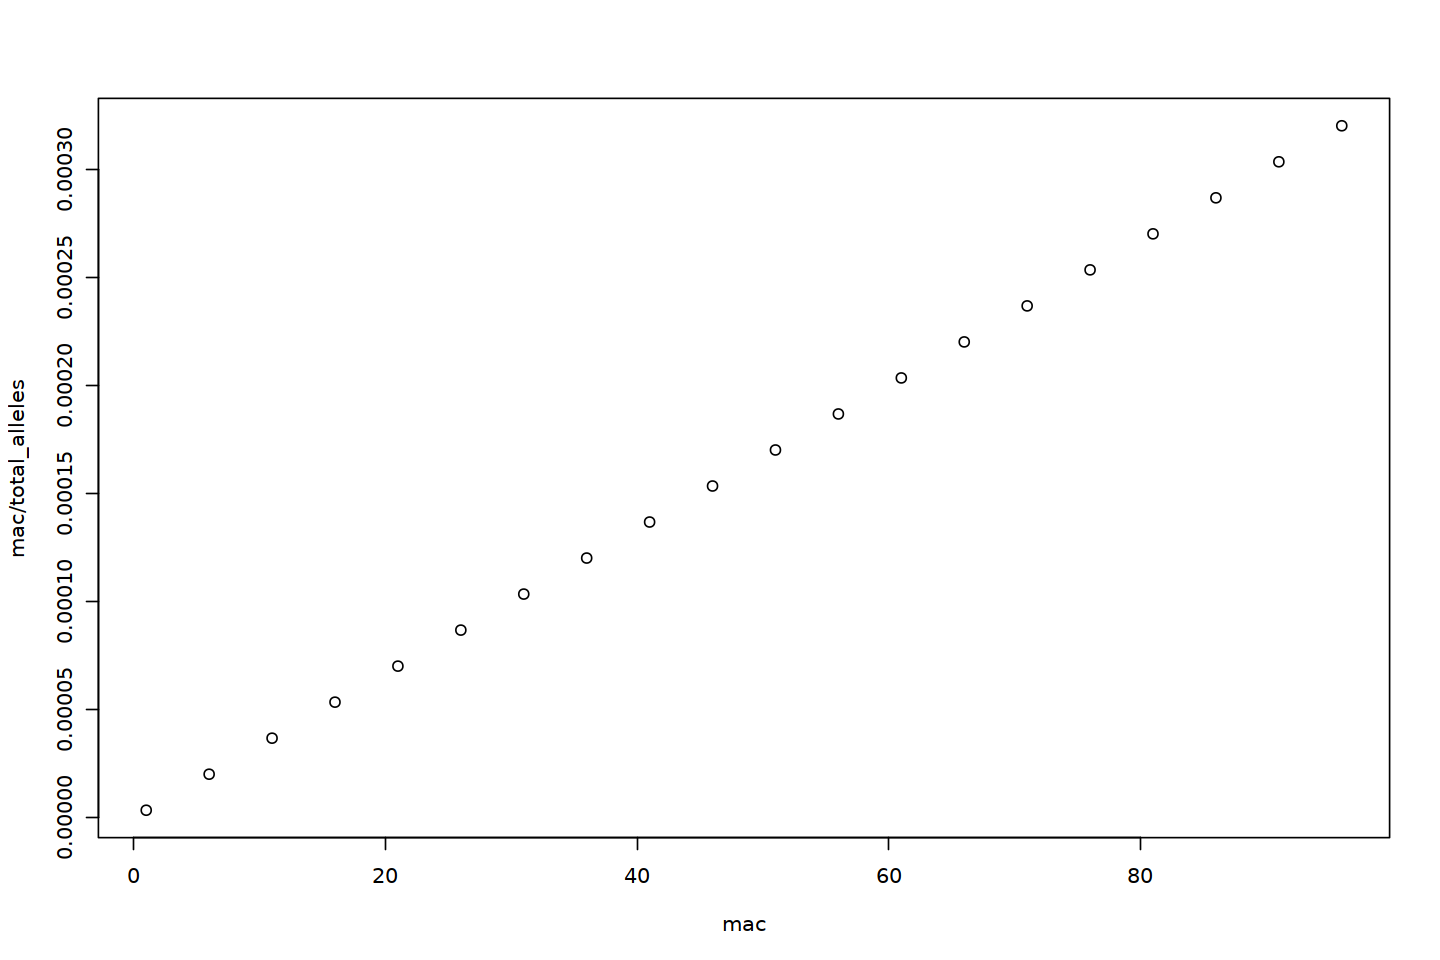

In [20]:
mac = seq(1, 100, by = 5)
total_alleles = 150000 * 2
plot(mac, mac / total_alleles)

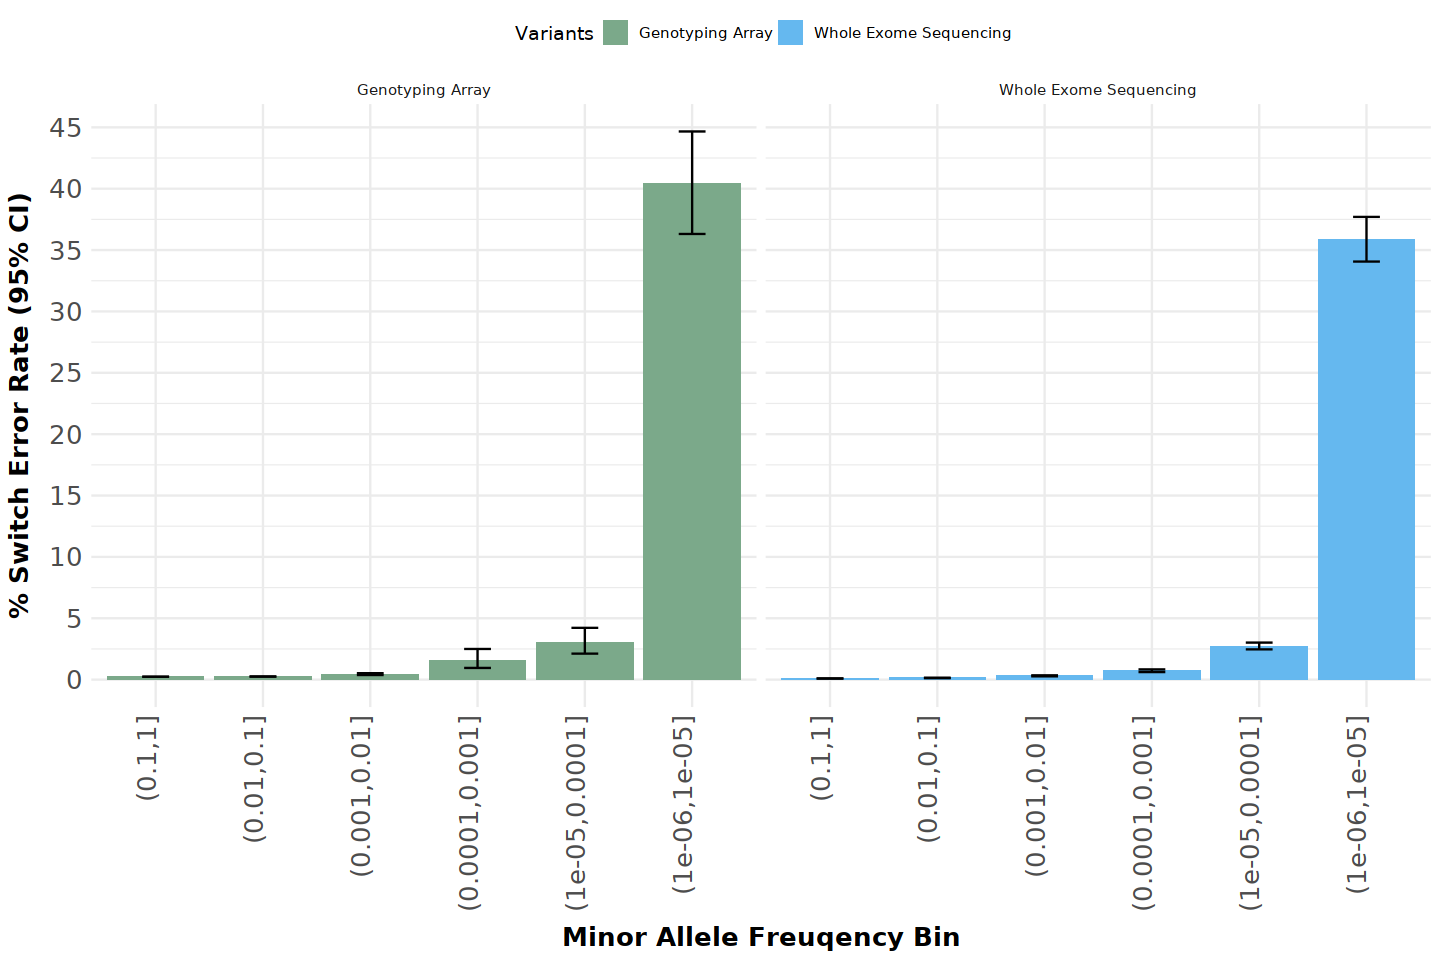

In [14]:
pd <- position_dodge(1)
p1 <- ggplot(d,
   aes(
       x=maf_bin,
       y=100*pointest,
       ymax = 100*upper,
       ymin = 100*lower,
       fill = wes_label,
   )) +
    theme_minimal() +
    geom_bar(stat = 'identity', position = pd, size = 1) +
    geom_errorbar(stat='identity', position = pd, width = 0.25) +
    ylab('% Switch Error Rate (95% CI)') + 
    xlab('Minor Allele Freuqency Bin') +
    fill_scale +
    labs(fill = "Hello") +
    scale_y_continuous(breaks=scales::pretty_breaks(n=10)) +
    theme(
        legend.position = "top",
        axis.text=element_text(size=15),
        axis.title=element_text(size=15,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5),
        axis.text.x = element_text(angle = 90, vjust = 0, hjust=1)
    ) +
    facet_wrap(~wes_label) 

p1

[1] 1e-06

In [17]:
d$wes_variant

[1] FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE FALSE  TRUE

In [18]:
path <- "data/phased/validation/220713_ukb_eur_wes_union_calls_phasing_eagle_shapeit4.txt.gz"
d <- fread(path)
d$wes_label <- factor(d$wes_label)
d$chunk_current_w_label <- paste0("p",d$chunk_current)
d <- d[d$CHR %in% c("chr21","chr22")]
head(d, n = 2)

wes_variant,chunk_current,CHR,switches,tested,method,pointest,lower,upper,wes_label,chunk_current_w_label
<lgl>,<int>,<chr>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
FALSE,1,chr21,256,147042,Eagle2,0.0017409992,0.0015405386,0.001967493,Genotyping Array,p1
TRUE,1,chr21,26,28489,Eagle2,0.0009126329,0.0006229079,0.001336934,Whole Exome Sequencing,p1


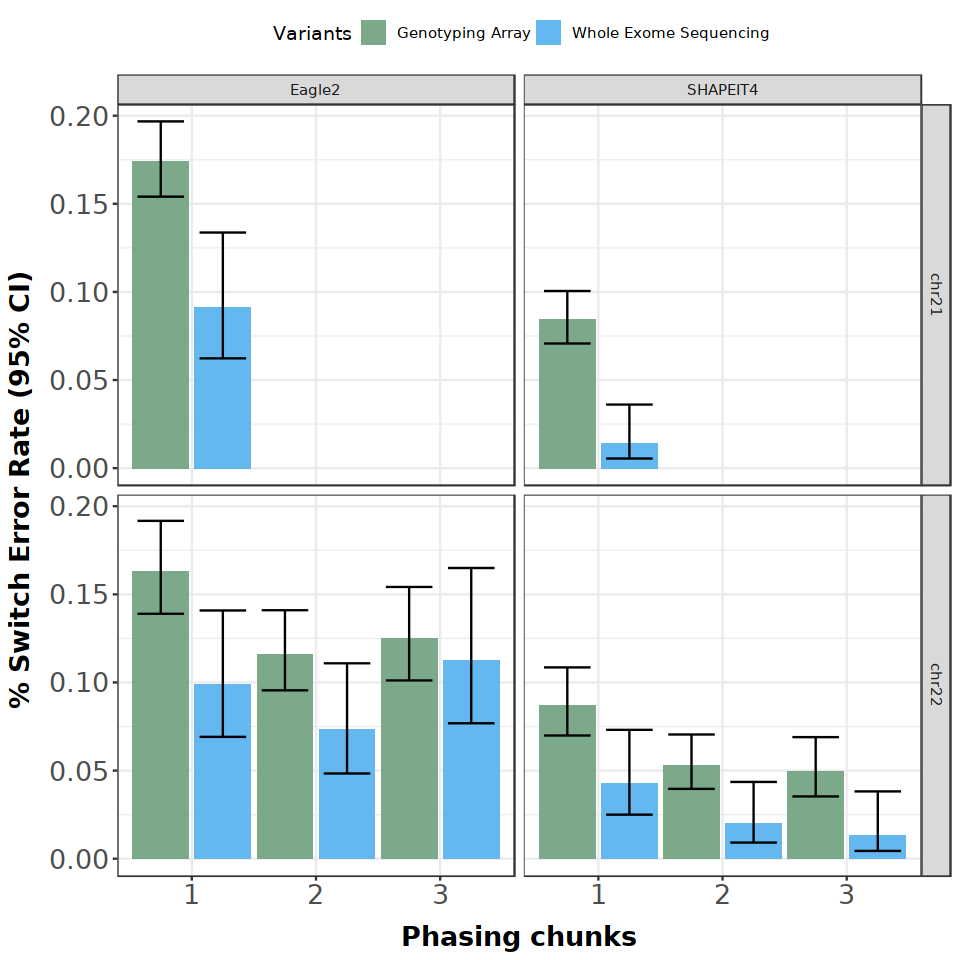

In [19]:
options(repr.plot.width=8, repr.plot.height=8)
pd <- position_dodge(1)
p1 <- ggplot(d,
   aes(
       x=factor(chunk_current),
       y=100*pointest,
       ymax = 100*upper,
       ymin = 100*lower,
       fill = wes_label,
   )) +
    theme_bw() +
    geom_bar(stat = 'identity', position = pd, size = 1) +
    geom_errorbar(stat='identity', position = pd,width = 0.75) +
    ylab('% Switch Error Rate (95% CI)') + 
    xlab('Phasing chunks') +
    fill_scale +
    labs(fill = "Hello") +
    #scale_y_continuous(breaks=scales::pretty_breaks(n=4)) +
    #scale_x_continuous(breaks=scales::pretty_breaks(n=7)) +
    facet_grid(CHR~method) +
    theme(
        legend.position = "top",
        axis.text=element_text(size=16),
        axis.title=element_text(size=16,face="bold"),
        axis.title.x = element_text(margin=ggplot2::margin(t=10)),
        axis.title.y = element_text(margin=ggplot2::margin(r=10)),
        plot.title = element_text(hjust=0.5)
       # axis.text.x = element_text(angle = 0, vjust = 1, hjust=0)
    )
    p1

In [20]:
options(repr.matrix.max.rows=270, repr.matrix.max.cols=30)
d

wes_variant,chunk_current,CHR,switches,tested,method,pointest,lower,upper,wes_label,chunk_current_w_label
<lgl>,<int>,<chr>,<int>,<int>,<chr>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
FALSE,1,chr21,256,147042,Eagle2,0.0017409992,1.540539e-03,0.0019674930,Genotyping Array,p1
TRUE,1,chr21,26,28489,Eagle2,0.0009126329,6.229079e-04,0.0013369338,Whole Exome Sequencing,p1
FALSE,1,chr22,148,90669,Eagle2,0.0016323109,1.389820e-03,0.0019170299,Genotyping Array,p1
TRUE,1,chr22,30,30397,Eagle2,0.0009869395,6.914383e-04,0.0014085516,Whole Exome Sequencing,p1
FALSE,2,chr22,101,87028,Eagle2,0.0011605460,9.552974e-04,0.0014098308,Genotyping Array,p2
TRUE,2,chr22,22,30039,Eagle2,0.0007323812,4.837249e-04,0.0011087163,Whole Exome Sequencing,p2
FALSE,3,chr22,86,68860,Eagle2,0.0012489108,1.011487e-03,0.0015419791,Genotyping Array,p3
TRUE,3,chr22,26,23089,Eagle2,0.0011260774,7.686132e-04,0.0016495153,Whole Exome Sequencing,p3
FALSE,1,chr21,124,147049,SHAPEIT4,0.0008432563,7.073669e-04,0.0010052247,Genotyping Array,p1


# compare old WES naive phasing with WES+GENO union

In [77]:
fread_phased_sites <- function(file, ...){

    # get details about chunks
    bname <- basename(file)
    chunk_current <- as.numeric(gsub("of","",stringr::str_extract(bname, "[0-9]+of")))
    chunk_final <- as.numeric(gsub("of","",stringr::str_extract(bname, "of[0-9]+")))
    method <- unlist(strsplit(bname, split = '_'))[1]
    phasing_region_size <- as.numeric(gsub("_prs","",stringr::str_extract(bname, "_prs[0-9]+")))
    phasing_overlap_size <- as.numeric(gsub("_pro","",stringr::str_extract(bname, "_pro[0-9]+")))
    max_phasing_region_size <- as.numeric(gsub("_mprs","",stringr::str_extract(bname, "_mprs[0-9]+")))

    # append to data.table
    d <- fread(file, ...)
    d$locus <- paste0(d$CHR,":",d$POS)
    d$chunk_current <- chunk_current
    d$chunk_final <- chunk_final
    d$method <- method
    d$phasing_region_size <- phasing_region_size
    d$phasing_overlap_size <- phasing_overlap_size
    d$max_phasing_region_size <- max_phasing_region_size
    return(d)

}

In [78]:
files_chr22 <- list.files("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/phased/wes/chunks/final/ukb_eur_wes_200k_chr22-18xshort.qe", pattern = '.txt', full.names = TRUE)
files_chr22 <- files_chr22[!grepl('shapeit4_prs150000_pro75000_mprs200000.1of1.txt', files_chr22)]

In [79]:
files_chr21 <- list.files("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb/data/phased/wes/chunks/final/ukb_eur_wes_200k_chr21-18xshort.qe/", pattern = '.txt', full.names = TRUE)
files_chr21 <- files_chr21[1]

In [80]:
files <- c(files_chr21, files_chr22)

In [87]:
chroms <- c("chr21","chr22")
lst <- lapply(chroms, function(chr){

    # subset by chromosome (if we read in all at the same time it takes too long)
    files_chr <- files[grepl(paste0(chr,"-"), files)]
    d <- data.table(do.call(rbind, lapply(files_chr, fread_phased_sites)))
    d$wes_variant <- TRUE

    # get counts
    counts <- aggregate(switches ~ wes_variant + chunk_current + CHR, data = d, FUN = sum)
    tested <- aggregate(switches ~ wes_variant + chunk_current + CHR, data = d, FUN = length)
    counts <- data.table(counts, tested = tested$switches)
    return(counts)
})


In [88]:
# combine counts and add conf int
counts <- do.call(rbind, lst)
counts_ci <- do.call(rbind, lapply(1:nrow(counts), function(i) Hmisc::binconf(counts$switches[i], counts$tested[i])))
colnames(counts_ci) <- tolower(colnames(counts_ci))
counts <- cbind(counts, counts_ci)

In [90]:
counts

wes_variant,chunk_current,CHR,switches,tested,pointest,lower,upper
<lgl>,<dbl>,<chr>,<int>,<int>,<dbl>,<dbl>,<dbl>
TRUE,1,chr21,1173,22094,0.053091337,0.05021177,0.056126283
TRUE,1,chr22,696,24130,0.028843763,0.02680586,0.031031659
TRUE,2,chr22,325,25379,0.012805863,0.01149444,0.014264755
TRUE,3,chr22,126,16905,0.007453416,0.00626408,0.008866552
